In [4]:
from google.colab import drive
drive.mount('/content/drive')

!unzip /content/drive/MyDrive/file.zip -d /content/output_folder

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
unzip:  cannot find or open /content/drive/MyDrive/file.zip, /content/drive/MyDrive/file.zip.zip or /content/drive/MyDrive/file.zip.ZIP.


In [5]:
!find /content/drive -iname "*News Category Dataset*.zip"

/content/drive/MyDrive/AI_Coursework/6. News Category Dataset-20260509T045200Z-3-001.zip


In [6]:
import zipfile

with zipfile.ZipFile('/content/drive/MyDrive/AI_Coursework/6. News Category Dataset-20260509T045200Z-3-001.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [7]:
import os
print(os.listdir())

['.config', '6. News Category Dataset', 'drive', 'sample_data']


# 6CS012 NLP Portfolio — Task 4.5
## Headline Category Prediction using RNN, LSTM, and Word2Vec
---
**Dataset:** 11,025 news headlines · 5 categories: SPORTS, TECH, MONEY, CULTURE & ARTS, EDUCATION  
**Models:** Simple RNN · LSTM · LSTM + pretrained GloVe embeddings

## 0 — Install Dependencies

In [8]:
!pip install -q tensorflow gensim nltk wordcloud contractions matplotlib seaborn scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.1 MB/s eta 0:00:00


## 0.1 — Imports

In [9]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score,
    f1_score, precision_score, recall_score
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

import gensim.downloader as api

for pkg in ['stopwords', 'wordnet', 'omw-1.4', 'punkt']:
    nltk.download(pkg, quiet=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#455A64', '#78909C', '#B0BEC5']   # variant_4_slate chart colours   # blue · green · orange

print(f'Environment check complete · TensorFlow {tf.__version__} is available.')

Environment check complete · TensorFlow 2.20.0 is available.


---
## 4.5.1 — Text Preprocessing, Tokenization, and Sequence Padding

### Step 1 — Load Dataset

In [10]:
# ════════════════════════════════════════════════════
# TODO: replace with your actual file path
# e.g. '/content/drive/MyDrive/news_headlines.csv'
# ════════════════════════════════════════════════════
DATASET_PATH = '6. News Category Dataset/news_category.csv'

df = pd.read_csv(DATASET_PATH)   # tab-separated
# comma-separated → df = pd.read_csv(DATASET_PATH)

print(f'Shape   : {df.shape}')
print(f'Columns : {df.columns}')
df.head()

Shape   : (11025, 2)
Columns : Index(['headline', 'category'], dtype='object')


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


Category distribution:
category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014

Unique categories : 5
Imbalance ratio   : 5.01x


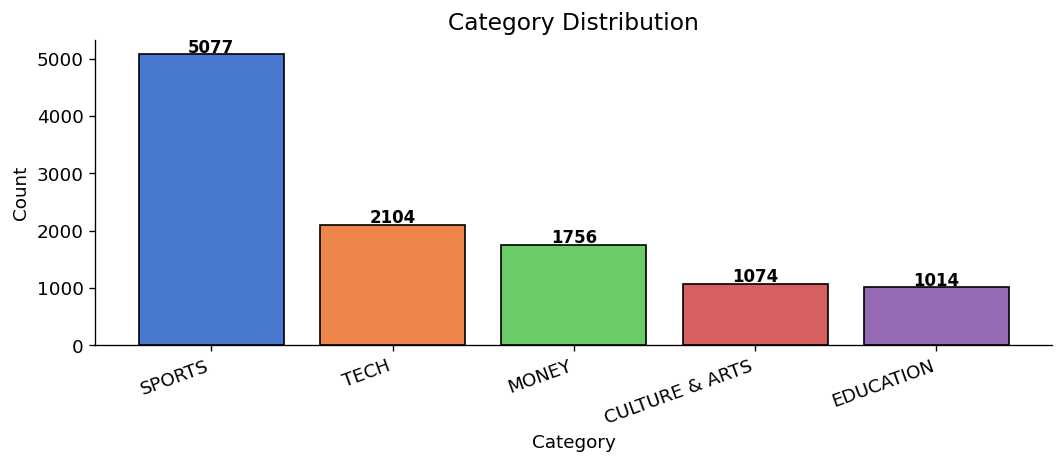

In [11]:
cat_counts = df['category'].value_counts()
print('Category distribution:')
print(cat_counts.to_string())
print(f'\nUnique categories : {df["category"].nunique()}')
print(f'Imbalance ratio   : {cat_counts.iloc[0]/cat_counts.iloc[-1]:.2f}x')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cat_counts.index, cat_counts.values,
              color=sns.color_palette('muted', len(cat_counts)), edgecolor='black')
for bar, v in zip(bars, cat_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(v), ha='center', fontsize=10, fontweight='bold')
ax.set_title('Category Distribution', fontsize=14)
ax.set_xlabel('Category'); ax.set_ylabel('Count')
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.savefig('category_distribution.png'); plt.show()

### Step 2 — Text Cleaning

In [12]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Pipeline:
      1. Lowercase
      2. Expand contractions  (don't → do not)
      3. Remove URLs
      4. Remove @mentions and #hashtags
      5. Remove numbers and special characters
      6. Remove stopwords
      7. Lemmatize
    """
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'_', ' ', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['headline'].apply(clean_text)

print('Sample cleaned headlines:')
for i in range(5):
    print(f'  Original : {df["headline"].iloc[i]}')
    print(f'  Cleaned  : {df["clean_text"].iloc[i]}')
    print(f'  Category : {df["category"].iloc[i]}\n')

Sample cleaned headlines:
  Original : How A New Documentary Captures The Complexity Of Being A Child Of Immigrants
  Cleaned  : new documentary capture complexity child immigrant
  Category : CULTURE & ARTS

  Original : Twitch Bans Gambling Sites After Streamer Scams Folks Out Of $200,000
  Cleaned  : twitch ban gambling site streamer scam folk
  Category : TECH

  Original : 'Reboot' Is A Clever And Not Too Navel-Gazey Look Inside TV Reboots
  Cleaned  : reboot clever navelgazey look inside tv reboots
  Category : CULTURE & ARTS

  Original : Maury Wills, Base-Stealing Shortstop For Dodgers, Dies At 89
  Cleaned  : maury will basestealing shortstop dodger dy
  Category : SPORTS

  Original : Las Vegas Aces Win First WNBA Title, Chelsea Gray Named MVP
  Cleaned  : la vega ace win first wnba title chelsea gray named mvp
  Category : SPORTS



### Step 3 — Visualise Cleaned Data

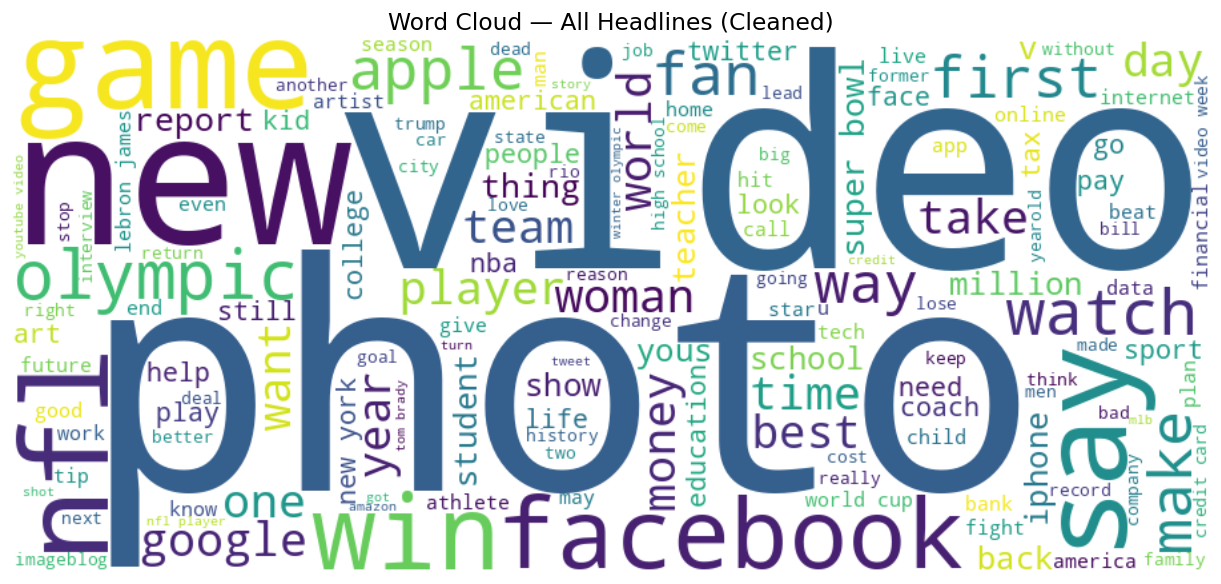

In [13]:
all_text = ' '.join(df['clean_text'])
wc = WordCloud(width=900, height=400, background_color='white',
               colormap='viridis', max_words=150).generate(all_text)
plt.figure(figsize=(13, 5))
plt.imshow(wc, interpolation='bilinear'); plt.axis('off')
plt.title('Word Cloud — All Headlines (Cleaned)', fontsize=14)
plt.tight_layout(); plt.savefig('wordcloud_all.png'); plt.show()

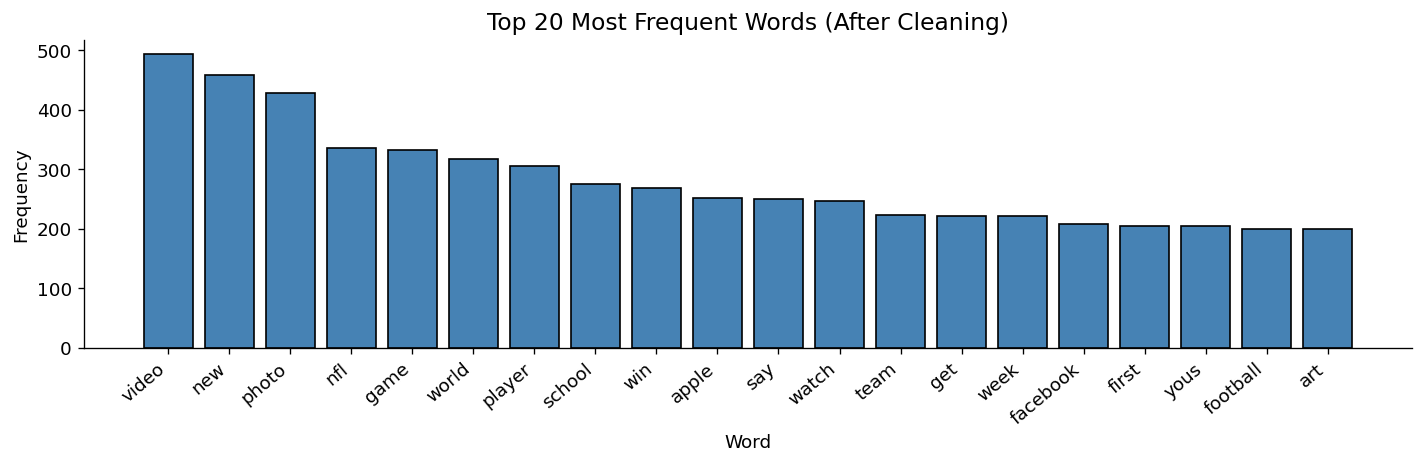

In [14]:
word_freq = Counter(all_text.split())
words, counts = zip(*word_freq.most_common(20))
plt.figure(figsize=(12, 4))
plt.bar(words, counts, color='steelblue', edgecolor='black')
plt.title('Top 20 Most Frequent Words (After Cleaning)', fontsize=14)
plt.xlabel('Word'); plt.ylabel('Frequency')
plt.xticks(rotation=40, ha='right')
plt.tight_layout(); plt.savefig('top_words.png'); plt.show()

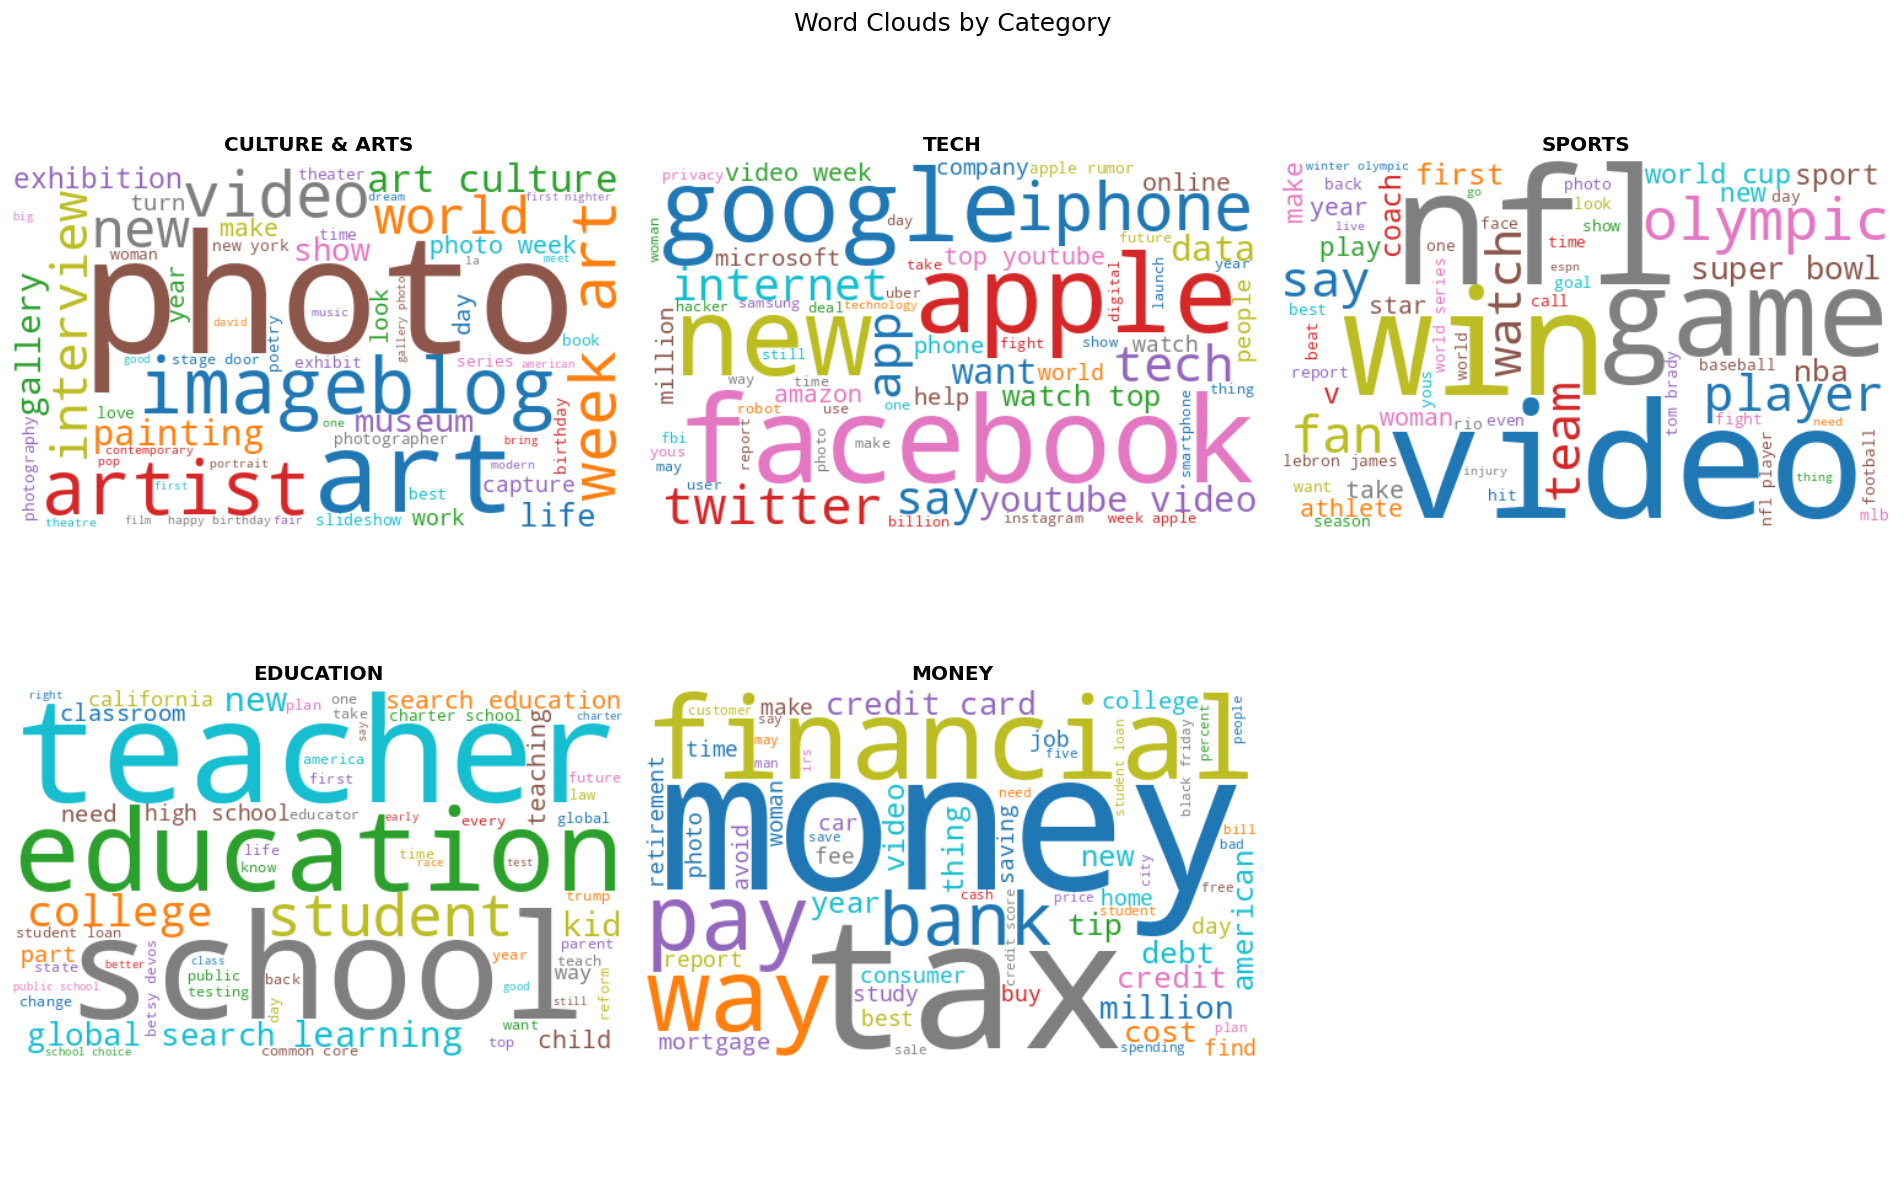

In [15]:
categories = df['category'].unique()
ncols = 3; nrows = int(np.ceil(len(categories) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()
for i, cat in enumerate(categories):
    cat_text = ' '.join(df[df['category'] == cat]['clean_text'])
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap='tab10', max_words=60).generate(cat_text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(cat, fontsize=12, fontweight='bold'); axes[i].axis('off')
for j in range(i + 1, len(axes)): axes[j].axis('off')
plt.suptitle('Word Clouds by Category', fontsize=15)
plt.tight_layout(); plt.savefig('wordcloud_by_category.png'); plt.show()

### Step 4 — Label Encoding, Train/Test Split, Tokenization & Padding

In [16]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])
NUM_CLASSES  = df['label'].nunique()
CLASS_NAMES  = label_encoder.classes_.tolist()

print(f'Number of classes: {NUM_CLASSES}')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {i} → {cls}')

Number of classes: 5
  0 → CULTURE & ARTS
  1 → EDUCATION
  2 → MONEY
  3 → SPORTS
  4 → TECH


In [17]:
X = df['clean_text'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Training samples : 8820
Testing  samples : 2205


In [18]:

VOCAB_SIZE    = 5000
MAX_LEN       = 12
EMBEDDING_DIM = 64
RNN_UNITS     = 32
DENSE_UNITS   = 32
DROPOUT_RATE  = 0.5
EPOCHS        = 30
BATCH_SIZE    = 32
VAL_SPLIT     = 0.1
LR            = 1e-3

print(f'VOCAB_SIZE={VOCAB_SIZE} | MAX_LEN={MAX_LEN} | EMBEDDING_DIM={EMBEDDING_DIM}')
print(f'RNN_UNITS={RNN_UNITS}   | DROPOUT={DROPOUT_RATE} | LR={LR}')

VOCAB_SIZE=5000 | MAX_LEN=12 | EMBEDDING_DIM=64
RNN_UNITS=32   | DROPOUT=0.5 | LR=0.001


In [19]:
# Class weights to handle 5x SPORTS vs EDUCATION imbalance
cw_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(cw_arr))
print('Class weights:')
for idx, w in class_weights.items():
    print(f'  {CLASS_NAMES[idx]:<20} → {w:.3f}')

Class weights:
  CULTURE & ARTS       → 2.054
  EDUCATION            → 2.175
  MONEY                → 1.256
  SPORTS               → 0.434
  TECH                 → 1.048


In [20]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)   # fit ONLY on training data

train_seq = tokenizer.texts_to_sequences(X_train)
test_seq  = tokenizer.texts_to_sequences(X_test)

print(f'Actual vocab size : {len(tokenizer.word_index)}')
print(f'Sample sequence   : {train_seq[0]}')

Actual vocab size : 11998
Sample sequence   : [63, 66, 11, 368, 2118, 776]


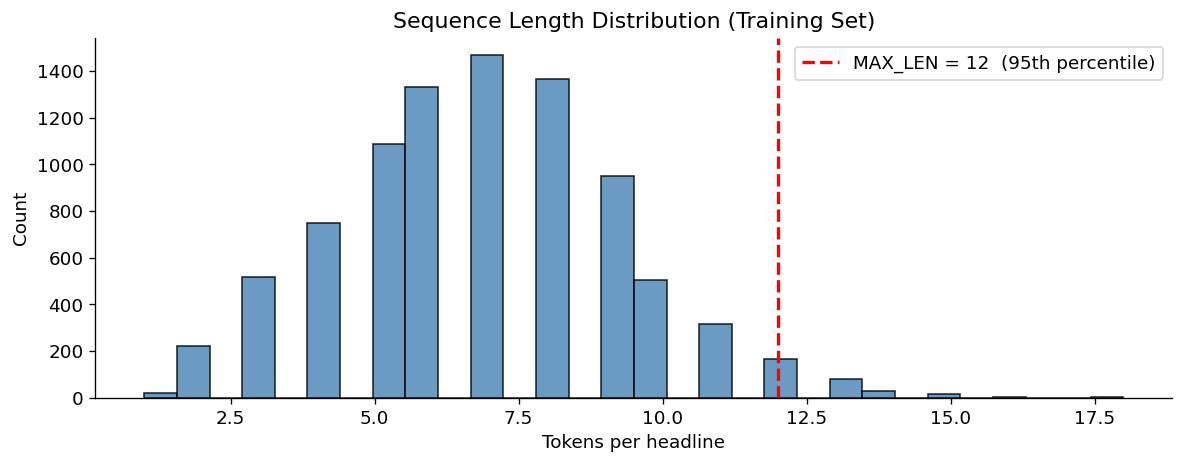

Mean=6.8  Median=7.0  95th%=11  MAX_LEN=12


In [21]:
seq_lens = [len(s) for s in train_seq]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(seq_lens, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2,
           label=f'MAX_LEN = {MAX_LEN}  (95th percentile)')
ax.set_title('Sequence Length Distribution (Training Set)')
ax.set_xlabel('Tokens per headline'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout(); plt.savefig('sequence_lengths.png'); plt.show()
print(f'Mean={np.mean(seq_lens):.1f}  Median={np.median(seq_lens):.1f}  '
      f'95th%={np.percentile(seq_lens,95):.0f}  MAX_LEN={MAX_LEN}')

In [22]:
X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')
print(f'X_train_pad : {X_train_pad.shape}')
print(f'X_test_pad  : {X_test_pad.shape}')

X_train_pad : (8820, 12)
X_test_pad  : (2205, 12)


---
## 4.5.2 — Model Building

| # | Model | Embedding | Recurrent Layer |
|---|-------|-----------|----------------|
| 1 | SimpleRNN | Trainable (64-dim) | SimpleRNN(32) |
| 2 | LSTM | Trainable (64-dim) | LSTM(32) |
| 3 | LSTM + GloVe | Pretrained GloVe-50 (frozen) | LSTM(32) |

In [23]:
LOSS_FN      = 'sparse_categorical_crossentropy'
OUTPUT_ACT   = 'softmax'
OUTPUT_UNITS = NUM_CLASSES

def make_callbacks():
    """Returns fresh callback instances (resets patience each call)."""
    es  = EarlyStopping(monitor='val_loss', patience=5,
                        restore_best_weights=True, verbose=1)
    rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                            patience=2, min_lr=1e-5, verbose=1)
    return [es, rlr]

### Model 1 — Simple RNN + Trainable Embedding

In [24]:
rnn_model = Sequential(name='SimpleRNN_Model')
rnn_model.add(Input(shape=(MAX_LEN,)))
rnn_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
rnn_model.add(SimpleRNN(RNN_UNITS, recurrent_dropout=0.3))
rnn_model.add(Dropout(DROPOUT_RATE))
rnn_model.add(Dense(DENSE_UNITS, activation='relu', kernel_regularizer=l2(0.001)))
rnn_model.add(Dropout(DROPOUT_RATE))
rnn_model.add(Dense(OUTPUT_UNITS, activation=OUTPUT_ACT))

rnn_model.compile(loss=LOSS_FN, optimizer=Adam(LR), metrics=['accuracy'])
rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 12, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 324,325 (1.24 MB)

 Trainable params: 324,325 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

### Model 2 — LSTM + Trainable Embedding

In [25]:
lstm_model = Sequential(name='LSTM_Model')
lstm_model.add(Input(shape=(MAX_LEN,)))
lstm_model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
lstm_model.add(LSTM(RNN_UNITS, recurrent_dropout=0.3))
lstm_model.add(Dropout(DROPOUT_RATE))
lstm_model.add(Dense(DENSE_UNITS, activation='relu', kernel_regularizer=l2(0.001)))
lstm_model.add(Dropout(DROPOUT_RATE))
lstm_model.add(Dense(OUTPUT_UNITS, activation=OUTPUT_ACT))

lstm_model.compile(loss=LOSS_FN, optimizer=Adam(LR), metrics=['accuracy'])
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 12, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,637 (1.27 MB)

 Trainable params: 333,637 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

### Model 3 — LSTM + Pretrained Word2Vec (GloVe 50-dim)

In [26]:
0
print('Loading GloVe embeddings (glove-wiki-gigaword-50)...')
embedding_model = api.load('glove-wiki-gigaword-50')
W2V_DIM = embedding_model.vector_size
print(f'Loaded! Vector dimension: {W2V_DIM}')

Loading GloVe embeddings (glove-wiki-gigaword-50)...
[==================================================] 100.0% 66.0/66.0MB downloaded
Loaded! Vector dimension: 50


In [27]:
word_index       = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, W2V_DIM))

found = 0
for word, idx in word_index.items():
    if idx < VOCAB_SIZE and word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found += 1

coverage = found / min(len(word_index), VOCAB_SIZE) * 100
print(f'Embedding matrix : {embedding_matrix.shape}')
print(f'Word coverage    : {found}/{min(len(word_index), VOCAB_SIZE)} ({coverage:.1f}%)')

Embedding matrix : (5000, 50)
Word coverage    : 4876/5000 (97.5%)


In [28]:
lstm_w2v_model = Sequential(name='LSTM_Word2Vec_Model')
lstm_w2v_model.add(Input(shape=(MAX_LEN,)))
lstm_w2v_model.add(Embedding(
    input_dim=VOCAB_SIZE, output_dim=W2V_DIM,
    weights=[embedding_matrix], trainable=False   # freeze pretrained weights
))
lstm_w2v_model.add(LSTM(RNN_UNITS, recurrent_dropout=0.3))
lstm_w2v_model.add(Dropout(DROPOUT_RATE))
lstm_w2v_model.add(Dense(DENSE_UNITS, activation='relu', kernel_regularizer=l2(0.001)))
lstm_w2v_model.add(Dropout(DROPOUT_RATE))
lstm_w2v_model.add(Dense(OUTPUT_UNITS, activation=OUTPUT_ACT))

lstm_w2v_model.compile(loss=LOSS_FN, optimizer=Adam(LR), metrics=['accuracy'])
lstm_w2v_model.summary()

Model: "LSTM_Word2Vec_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 12, 50)         │       250,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        10,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,845 (1022.83 KB)

 Trainable params: 11,845 (46.27 KB)

 Non-trainable params: 250,000 (976.56 KB)

---
## 4.5.3 — Training and Evaluation
Each model gets its own training curves and confusion matrix immediately after training.
A full side-by-side comparison follows at the end.

In [29]:
# ════════════════════════════════════════════════════
# Shared plotting helpers
# ════════════════════════════════════════════════════

def plot_training_curves(run_history, display_name, line_color):
    """Loss + accuracy curves immediately after training."""
    ep = range(1, len(run_history.history['loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(ep, run_history.history['loss'],     color=line_color, lw=2, label='Train Loss')
    ax1.plot(ep, run_history.history['val_loss'], color=line_color, lw=2, ls=':', label='Val Loss')
    ax1.set_title(f'{display_name} — Loss', fontsize=13)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, alpha=0.22)

    ax2.plot(ep, run_history.history['accuracy'],     color=line_color, lw=2, label='Train Acc')
    ax2.plot(ep, run_history.history['val_accuracy'], color=line_color, lw=2, ls=':', label='Val Acc')
    ax2.set_title(f'{display_name} — Accuracy', fontsize=13)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1.05); ax2.legend(); ax2.grid(True, alpha=0.22)

    plt.suptitle(f'Training Curves — {display_name}', fontsize=14, y=1.02)
    plt.tight_layout()
    safe = display_name.replace(' ', '_').replace(':', '').replace('+', 'plus')
    plt.savefig(f'curves_{safe}.png', bbox_inches='tight')
    plt.show()


def evaluate_and_plot(trained_model, display_name, line_color):
    """Prints classification report, draws confusion matrix. Returns (acc, predicted_ids)."""
    predicted_ids = np.argmax(trained_model.predict(X_test_pad, verbose=0), axis=1)
    acc    = accuracy_score(y_test, predicted_ids)

    print(f'\n{"="*62}')
    print(f'EVALUATION — {display_name}')
    print(f'{"="*62}')
    print(f'Test Accuracy : {acc*100:.2f}%')
    print('\nClassification Report:')
    print(classification_report(y_test, predicted_ids, target_names=CLASS_NAMES))

    cm   = confusion_matrix(y_test, predicted_ids)
    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap='Greys', xticks_rotation=30, colorbar=False)
    ax.set_title(f'Confusion Matrix — {display_name}', fontsize=13)
    plt.tight_layout()
    safe = display_name.replace(' ', '_').replace(':', '').replace('+', 'plus')
    plt.savefig(f'cm_{safe}.png', bbox_inches='tight')
    plt.show()

    return acc, predicted_ids


print('Visual and evaluation helpers prepared for variant_4_slate.')

Visual and evaluation helpers prepared for variant_4_slate.


---
### Train + Evaluate — Model 1: Simple RNN

In [30]:

# ════════════════════════════════════════════════════════════════
# SHARED: Sample 6 real headlines from the test set (stratified)
# Run this cell ONCE after the train/test split is done
# ════════════════════════════════════════════════════════════════

# Re-derive these in case this cell is run independently
# ── Re-derive everything needed, fully self-contained ──────────
NUM_CLASSES = len(label_encoder.classes_)
CLASS_NAMES = label_encoder.classes_.tolist()

# Rebuild X_test_raw from df using the exact same split as the main notebook
X_all_raw = df['headline'].values
y_all     = df['label'].values

_, X_test_raw, _, y_test_check = train_test_split(
    X_all_raw, y_all, test_size=0.2, random_state=42, stratify=y_all
)
# Sanity check — labels must match y_test from earlier split
assert np.array_equal(y_test_check, y_test), \
    "y_test mismatch — check that random_state=42 and stratify are consistent."

np.random.seed(51)

# Pick 6 indices — at least 1 from each class where possible
picked_demo_rows = []
for cls_idx in range(NUM_CLASSES):
    class_row_positions = np.where(y_test == cls_idx)[0]
    chosen_row = np.random.choice(class_row_positions, size=1, replace=False)
    picked_demo_rows.extend(chosen_row.tolist())

# If NUM_CLASSES < 6, fill remainder randomly
while len(picked_demo_rows) < 6:
    picked_demo_rows.append(np.random.randint(0, len(y_test)))

picked_demo_rows = picked_demo_rows[:6]  # cap at 6

SAMPLE_HEADLINES_RAW   = [X_test_raw[i]   for i in picked_demo_rows]
SAMPLE_HEADLINES_CLEAN = [X_test[i]       for i in picked_demo_rows]   # already cleaned
SAMPLE_TRUE_LABELS     = [CLASS_NAMES[y_test[i]] for i in picked_demo_rows]

print("Review sample headlines for variant_4_slate:")
for i, (h, l) in enumerate(zip(SAMPLE_HEADLINES_RAW, SAMPLE_TRUE_LABELS)):
    print(f"  {i+1}. [{l}]  {h}")


def predict_from_test_set(model, model_name):
    """
    Predict on the 6 sampled real test headlines and display a results table.
    Uses the already-padded sequences via index lookup so results
    are consistent with the official evaluation.
    """
    print(f"\n{'='*68}")
    print(f"  TEST-SET SAMPLE PREDICTION CHECK — {model_name}")
    print(f"{'='*68}")
    print(f"  {'#':<3} {'Headline (original)':<42} {'True':<16} {'Predicted':<16} {'Conf':>6}")
    print(f"  {'-'*3} {'-'*42} {'-'*16} {'-'*16} {'-'*6}")

    # Re-pad using the sampled cleaned texts to be safe
    seqs   = tokenizer.texts_to_sequences(SAMPLE_HEADLINES_CLEAN)
    padded = pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')
    probs  = model.predict(padded, verbose=0)
    preds  = [CLASS_NAMES[np.argmax(p)] for p in probs]

    correct = 0
    for i, (headline, true, pred, prob) in enumerate(
            zip(SAMPLE_HEADLINES_RAW, SAMPLE_TRUE_LABELS, preds, probs)):
        match   = "✓" if pred == true else "✗"
        conf    = np.max(prob) * 100
        h_short = headline[:41] + "…" if len(headline) > 42 else headline
        print(f"  {i+1:<3} {h_short:<42} {true:<16} {pred:<16} {conf:>5.1f}%  {match}")
        if pred == true:
            correct += 1

    print(f"\n  Sample accuracy: {correct}/{len(SAMPLE_HEADLINES_RAW)} "
          f"({correct/len(SAMPLE_HEADLINES_RAW)*100:.0f}%)")
    print(f"{'='*68}\n")


print("\nSample prediction helper is ready.")



Review sample headlines for variant_4_slate:
  1. [CULTURE & ARTS]  Carole Bayer Sager on the ImageBlog
  2. [EDUCATION]  The Power of Partnerships in Early Education
  3. [MONEY]  Top Credit Cards for Balance Transfers
  4. [SPORTS]  Russian Long Jumper Darya Klishina To Compete At Rio Olympics After Appeal Upheld
  5. [TECH]  This Is Why You Should Never Send A Terrorist Threat To An Airline On Twitter
  6. [EDUCATION]  Good but Not Good Enough: Moving Public Will on Early Childhood Education

Sample prediction helper is ready.


In [31]:
print('Starting run 1/3: SimpleRNN')
history1 = rnn_model.fit(
    X_train_pad, y_train,
    validation_split=VAL_SPLIT,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    class_weight=class_weights,
    verbose=1
)
print('Run 1/3 finished: SimpleRNN')

Starting run 1/3: SimpleRNN
Epoch 1/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.2155 - loss: 1.6904 - val_accuracy: 0.1621 - val_loss: 1.6481 - learning_rate: 0.0010
Epoch 2/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2217 - loss: 1.6407 - val_accuracy: 0.1270 - val_loss: 1.6379 - learning_rate: 0.0010
Epoch 3/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3006 - loss: 1.6061 - val_accuracy: 0.4819 - val_loss: 1.4504 - learning_rate: 0.0010
Epoch 4/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4524 - loss: 1.4946 - val_accuracy: 0.5612 - val_loss: 1.1098 - learning_rate: 0.0010
Epoch 5/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5001 - loss: 1.4025 - val_accuracy: 0.5964 - val_loss: 1.0284 - learning_rate: 0.0010
Epoch 6/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5542 - loss: 1.3280 - val_accuracy: 0.4921 - val_loss: 1.0238 - learning_rate: 0.0010
Epoch 7/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accu

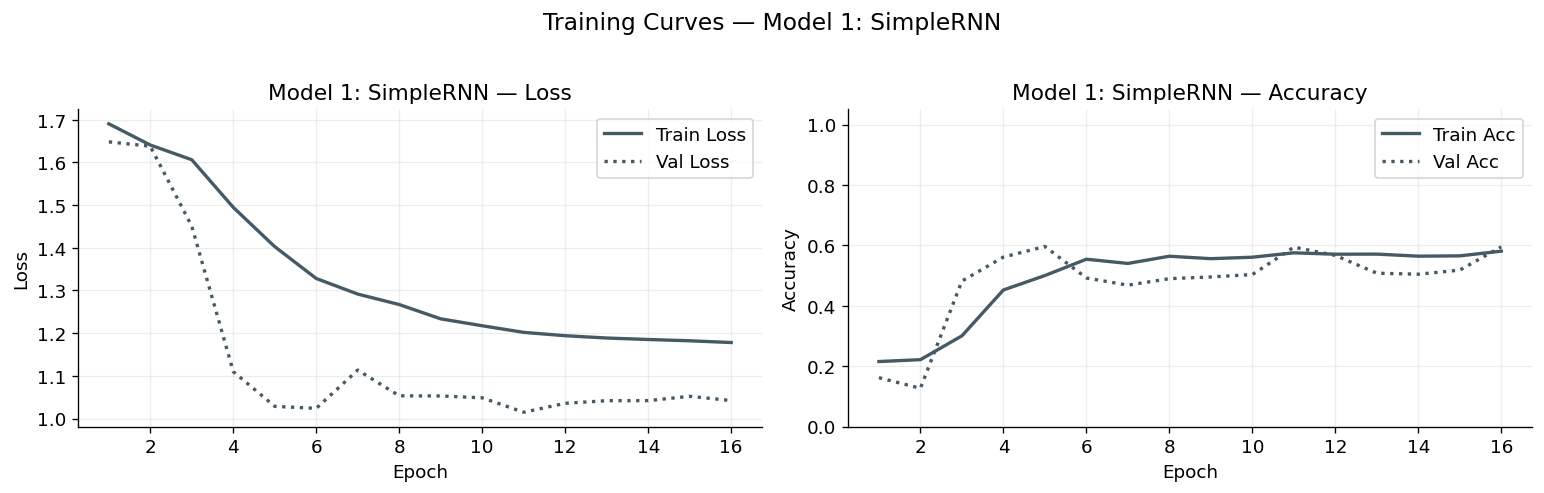


EVALUATION — Model 1: SimpleRNN
Test Accuracy : 56.64%

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.18      0.26      0.21       215
     EDUCATION       0.20      0.34      0.25       203
         MONEY       0.36      0.59      0.45       351
        SPORTS       0.93      0.90      0.92      1015
          TECH       0.00      0.00      0.00       421

      accuracy                           0.57      2205
     macro avg       0.34      0.42      0.37      2205
  weighted avg       0.52      0.57      0.54      2205



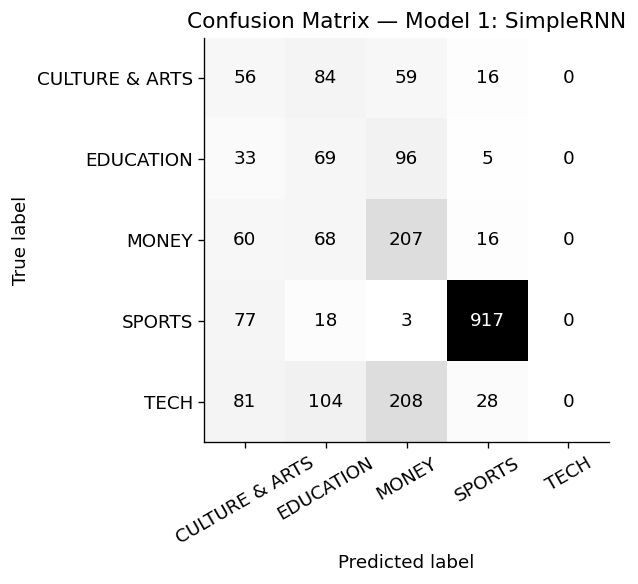

In [32]:
plot_training_curves(history1, 'Model 1: SimpleRNN', PALETTE[0])
acc1, pred1 = evaluate_and_plot(rnn_model, 'Model 1: SimpleRNN', PALETTE[0])

In [33]:
predict_from_test_set(rnn_model, "Model 1: SimpleRNN")



  TEST-SET SAMPLE PREDICTION CHECK — Model 1: SimpleRNN
  #   Headline (original)                        True             Predicted          Conf
  --- ------------------------------------------ ---------------- ---------------- ------
  1   Carole Bayer Sager on the ImageBlog        CULTURE & ARTS   CULTURE & ARTS    25.2%  ✓
  2   The Power of Partnerships in Early Educat… EDUCATION        MONEY             25.2%  ✗
  3   Top Credit Cards for Balance Transfers     MONEY            MONEY             25.3%  ✓
  4   Russian Long Jumper Darya Klishina To Com… SPORTS           SPORTS            99.3%  ✓
  5   This Is Why You Should Never Send A Terro… TECH             EDUCATION         25.1%  ✗
  6   Good but Not Good Enough: Moving Public W… EDUCATION        MONEY             25.5%  ✗

  Sample accuracy: 3/6 (50%)



---
### Train + Evaluate — Model 2: LSTM

In [34]:
print('Starting run 2/3: LSTM')
history2 = lstm_model.fit(
    X_train_pad, y_train,
    validation_split=VAL_SPLIT,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    class_weight=class_weights,
    verbose=1
)
print('Run 2/3 finished: LSTM')

Starting run 2/3: LSTM
Epoch 1/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.3020 - loss: 1.5562 - val_accuracy: 0.5737 - val_loss: 0.9822 - learning_rate: 0.0010
Epoch 2/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.6048 - loss: 1.1073 - val_accuracy: 0.6032 - val_loss: 0.8678 - learning_rate: 0.0010
Epoch 3/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.7099 - loss: 0.8965 - val_accuracy: 0.7596 - val_loss: 0.7468 - learning_rate: 0.0010
Epoch 4/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.7967 - loss: 0.7089 - val_accuracy: 0.7993 - val_loss: 0.6426 - learning_rate: 0.0010
Epoch 5/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.8576 - loss: 0.5419 - val_accuracy: 0.8005 - val_loss: 0.6964 - learning_rate: 0.0010
Epoch 6/30
248/249 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8976 - loss: 0.4113
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
249/249 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step -

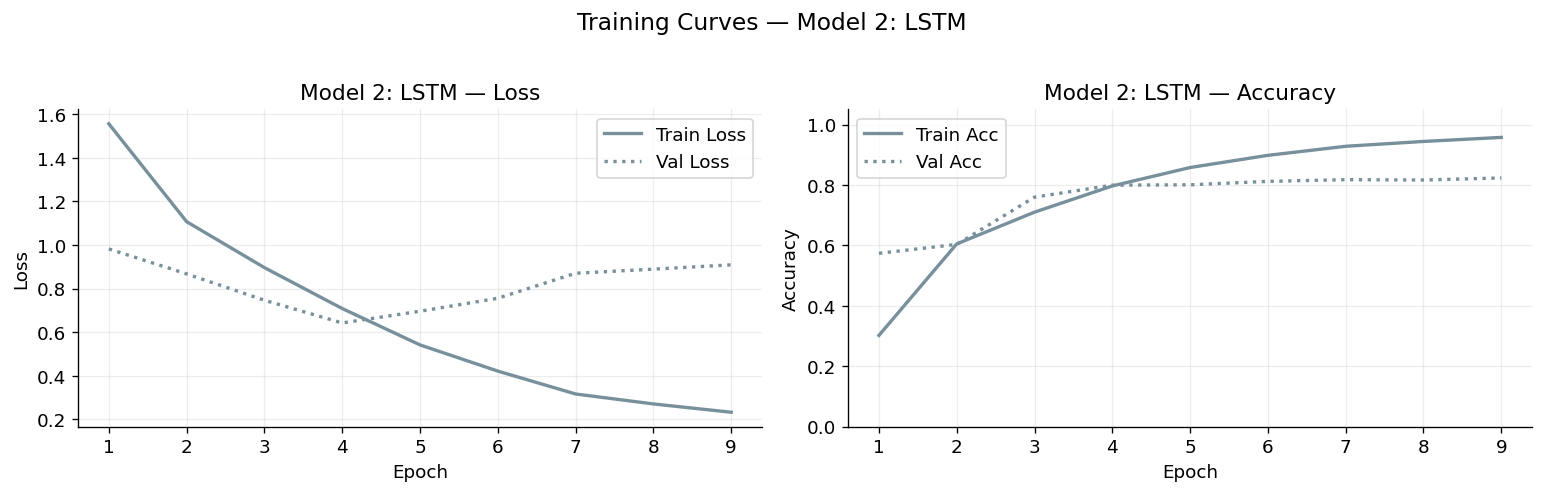


EVALUATION — Model 2: LSTM
Test Accuracy : 79.46%

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.66      0.80      0.72       215
     EDUCATION       0.49      0.63      0.55       203
         MONEY       0.68      0.76      0.71       351
        SPORTS       0.94      0.89      0.91      1015
          TECH       0.86      0.68      0.76       421

      accuracy                           0.79      2205
     macro avg       0.73      0.75      0.73      2205
  weighted avg       0.81      0.79      0.80      2205



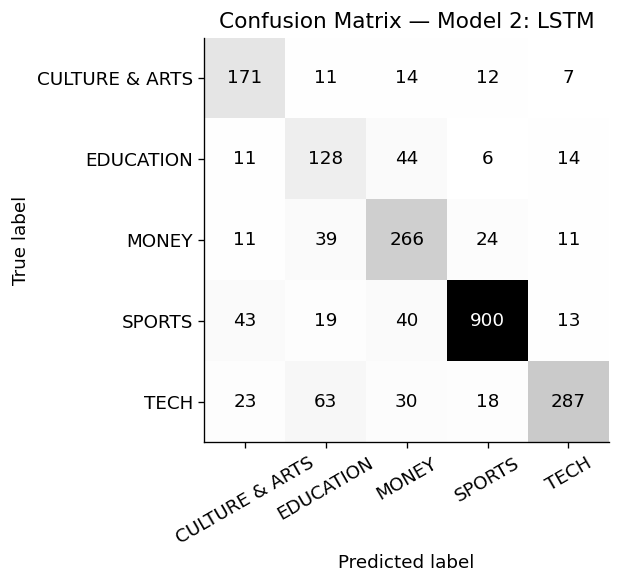

In [35]:
plot_training_curves(history2, 'Model 2: LSTM', PALETTE[1])
acc2, pred2 = evaluate_and_plot(lstm_model, 'Model 2: LSTM', PALETTE[1])

In [36]:
predict_from_test_set(lstm_model, "Model 2: LSTM")



  TEST-SET SAMPLE PREDICTION CHECK — Model 2: LSTM
  #   Headline (original)                        True             Predicted          Conf
  --- ------------------------------------------ ---------------- ---------------- ------
  1   Carole Bayer Sager on the ImageBlog        CULTURE & ARTS   CULTURE & ARTS    99.5%  ✓
  2   The Power of Partnerships in Early Educat… EDUCATION        EDUCATION         54.3%  ✓
  3   Top Credit Cards for Balance Transfers     MONEY            MONEY             91.2%  ✓
  4   Russian Long Jumper Darya Klishina To Com… SPORTS           SPORTS            90.3%  ✓
  5   This Is Why You Should Never Send A Terro… TECH             TECH              56.6%  ✓
  6   Good but Not Good Enough: Moving Public W… EDUCATION        TECH              47.4%  ✗

  Sample accuracy: 5/6 (83%)



---
### Train + Evaluate — Model 3: LSTM + Word2Vec

In [37]:
print('Starting run 3/3: LSTM + Word2Vec')
history3 = lstm_w2v_model.fit(
    X_train_pad, y_train,
    validation_split=VAL_SPLIT,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=make_callbacks(),
    class_weight=class_weights,
    verbose=1
)
print('Run 3/3 finished: LSTM + Word2Vec')

Starting run 3/3: LSTM + Word2Vec
Epoch 1/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.5296 - loss: 1.4004 - val_accuracy: 0.7460 - val_loss: 0.8143 - learning_rate: 0.0010
Epoch 2/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.7086 - loss: 1.0057 - val_accuracy: 0.7857 - val_loss: 0.6703 - learning_rate: 0.0010
Epoch 3/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.7492 - loss: 0.8902 - val_accuracy: 0.7993 - val_loss: 0.6106 - learning_rate: 0.0010
Epoch 4/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.7755 - loss: 0.8049 - val_accuracy: 0.8095 - val_loss: 0.5795 - learning_rate: 0.0010
Epoch 5/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.7868 - loss: 0.7737 - val_accuracy: 0.8197 - val_loss: 0.5687 - learning_rate: 0.0010
Epoch 6/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.8026 - loss: 0.7309 - val_accuracy: 0.8141 - val_loss: 0.5846 - learning_rate: 0.0010
Epoch 7/30
249/249 ━━━━━━━━━━━━━━━━━━━━ 11

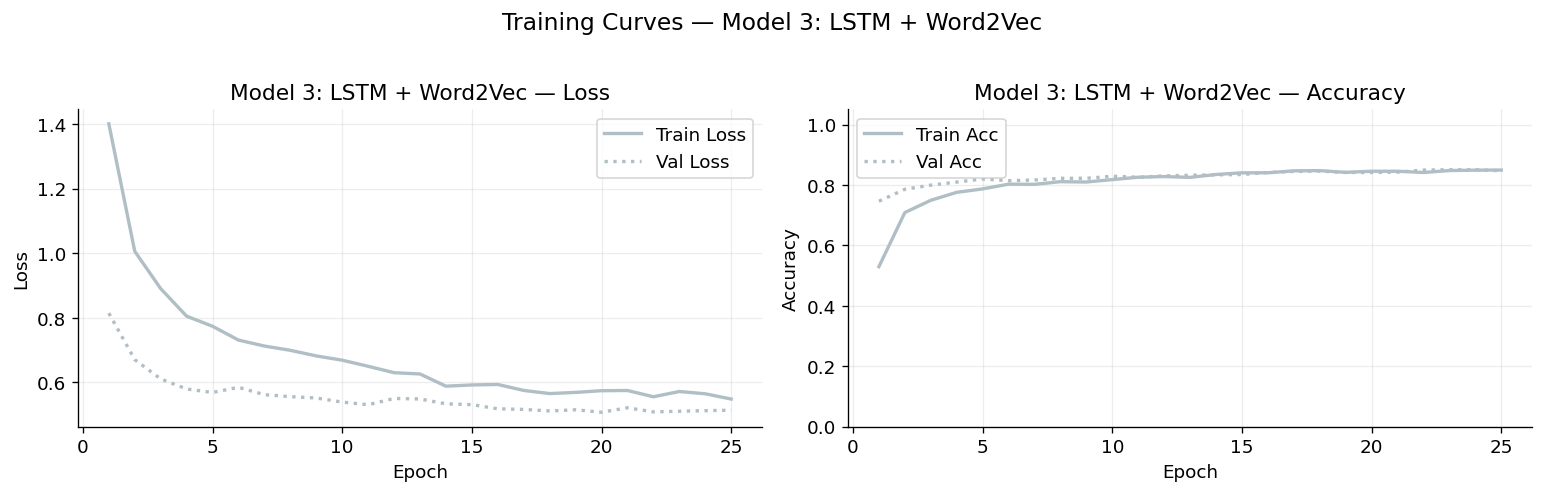


EVALUATION — Model 3: LSTM + Word2Vec
Test Accuracy : 82.49%

Classification Report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.63      0.82      0.71       215
     EDUCATION       0.62      0.74      0.68       203
         MONEY       0.79      0.75      0.77       351
        SPORTS       0.95      0.87      0.91      1015
          TECH       0.83      0.81      0.82       421

      accuracy                           0.82      2205
     macro avg       0.76      0.80      0.78      2205
  weighted avg       0.84      0.82      0.83      2205



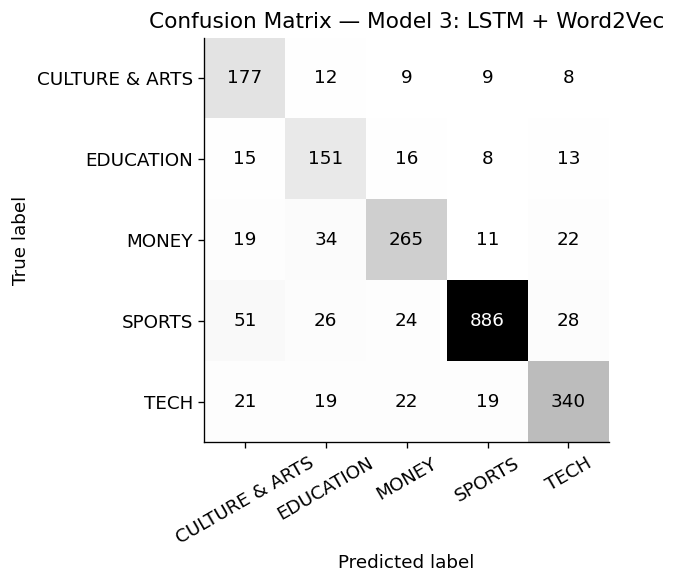

In [38]:
plot_training_curves(history3, 'Model 3: LSTM + Word2Vec', PALETTE[2])
acc3, pred3 = evaluate_and_plot(lstm_w2v_model, 'Model 3: LSTM + Word2Vec', PALETTE[2])

In [39]:
predict_from_test_set(lstm_w2v_model, "Model 3: LSTM + Word2Vec")



  TEST-SET SAMPLE PREDICTION CHECK — Model 3: LSTM + Word2Vec
  #   Headline (original)                        True             Predicted          Conf
  --- ------------------------------------------ ---------------- ---------------- ------
  1   Carole Bayer Sager on the ImageBlog        CULTURE & ARTS   CULTURE & ARTS    63.4%  ✓
  2   The Power of Partnerships in Early Educat… EDUCATION        EDUCATION         99.3%  ✓
  3   Top Credit Cards for Balance Transfers     MONEY            MONEY             98.6%  ✓
  4   Russian Long Jumper Darya Klishina To Com… SPORTS           SPORTS            98.9%  ✓
  5   This Is Why You Should Never Send A Terro… TECH             TECH              98.0%  ✓
  6   Good but Not Good Enough: Moving Public W… EDUCATION        EDUCATION         98.9%  ✓

  Sample accuracy: 6/6 (100%)



---
## Final Comparison — All Three Models
Four comparison plots:
1. Overlaid validation loss & accuracy curves
2. Test accuracy bar chart
3. Side-by-side confusion matrices
4. Per-class F1 grouped bar chart
5. Summary table

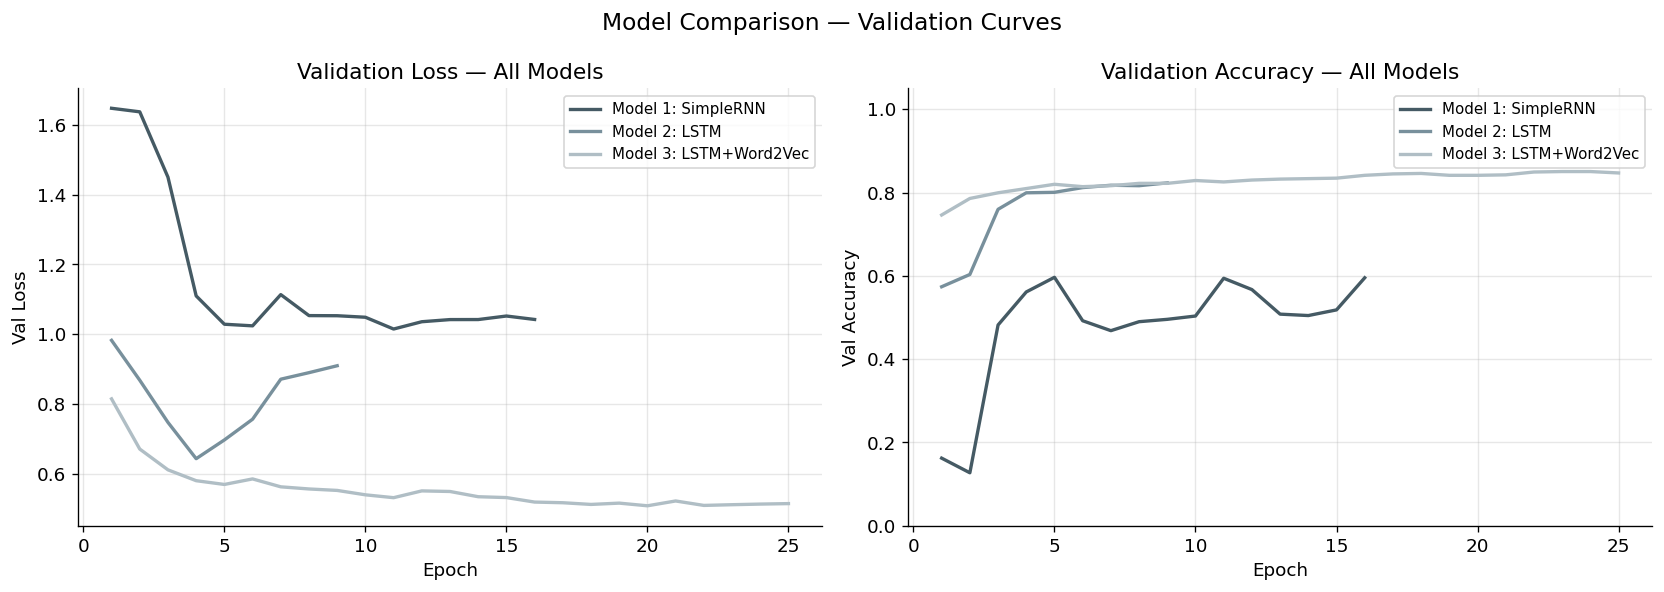

In [40]:
# ── 1. Overlaid validation curves ───────────────────────────
MODEL_LABELS = ['Model 1: SimpleRNN', 'Model 2: LSTM', 'Model 3: LSTM+Word2Vec']
HISTORIES    = [history1, history2, history3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for hist, label, color in zip(HISTORIES, MODEL_LABELS, PALETTE):
    ep = range(1, len(hist.history['loss']) + 1)
    ax1.plot(ep, hist.history['val_loss'],     color=color, lw=2, label=label)
    ax2.plot(ep, hist.history['val_accuracy'], color=color, lw=2, label=label)

ax1.set_title('Validation Loss — All Models', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val Loss')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

ax2.set_title('Validation Accuracy — All Models', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Val Accuracy')
ax2.set_ylim(0, 1.05); ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.suptitle('Model Comparison — Validation Curves', fontsize=14)
plt.tight_layout()
plt.savefig('comparison_val_curves.png', bbox_inches='tight')
plt.show()

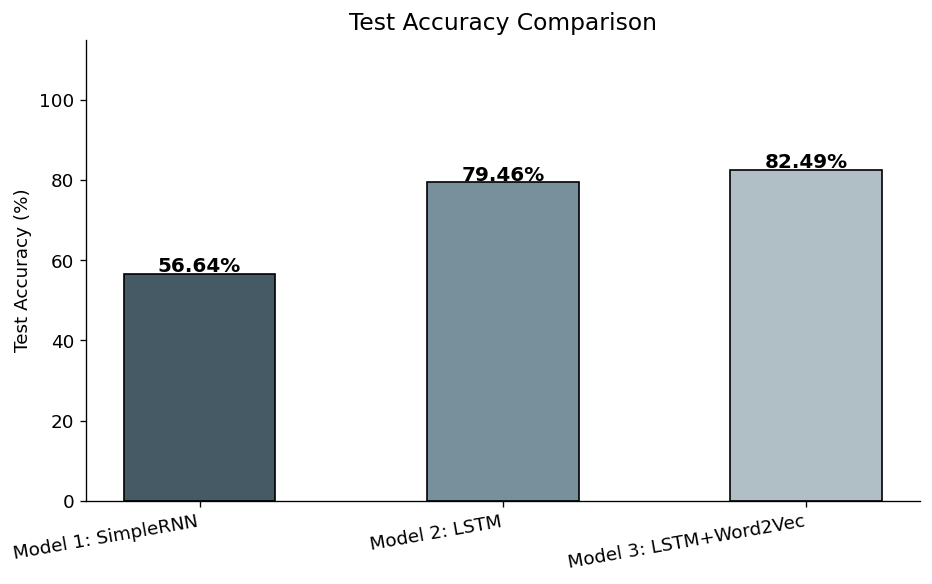

Top performing model: Model 3: LSTM+Word2Vec  (82.49%)


In [41]:
# ── 2. Test accuracy bar chart ───────────────────────────────
accs = [acc1, acc2, acc3]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(MODEL_LABELS, [a * 100 for a in accs],
              color=PALETTE, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{acc*100:.2f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_title('Test Accuracy Comparison', fontsize=14)
ax.set_ylabel('Test Accuracy (%)')
plt.xticks(rotation=10, ha='right')
plt.tight_layout()
plt.savefig('comparison_accuracy_bar.png', bbox_inches='tight')
plt.show()

best_idx = int(np.argmax(accs))
print(f'Top performing model: {MODEL_LABELS[best_idx]}  ({accs[best_idx]*100:.2f}%)')

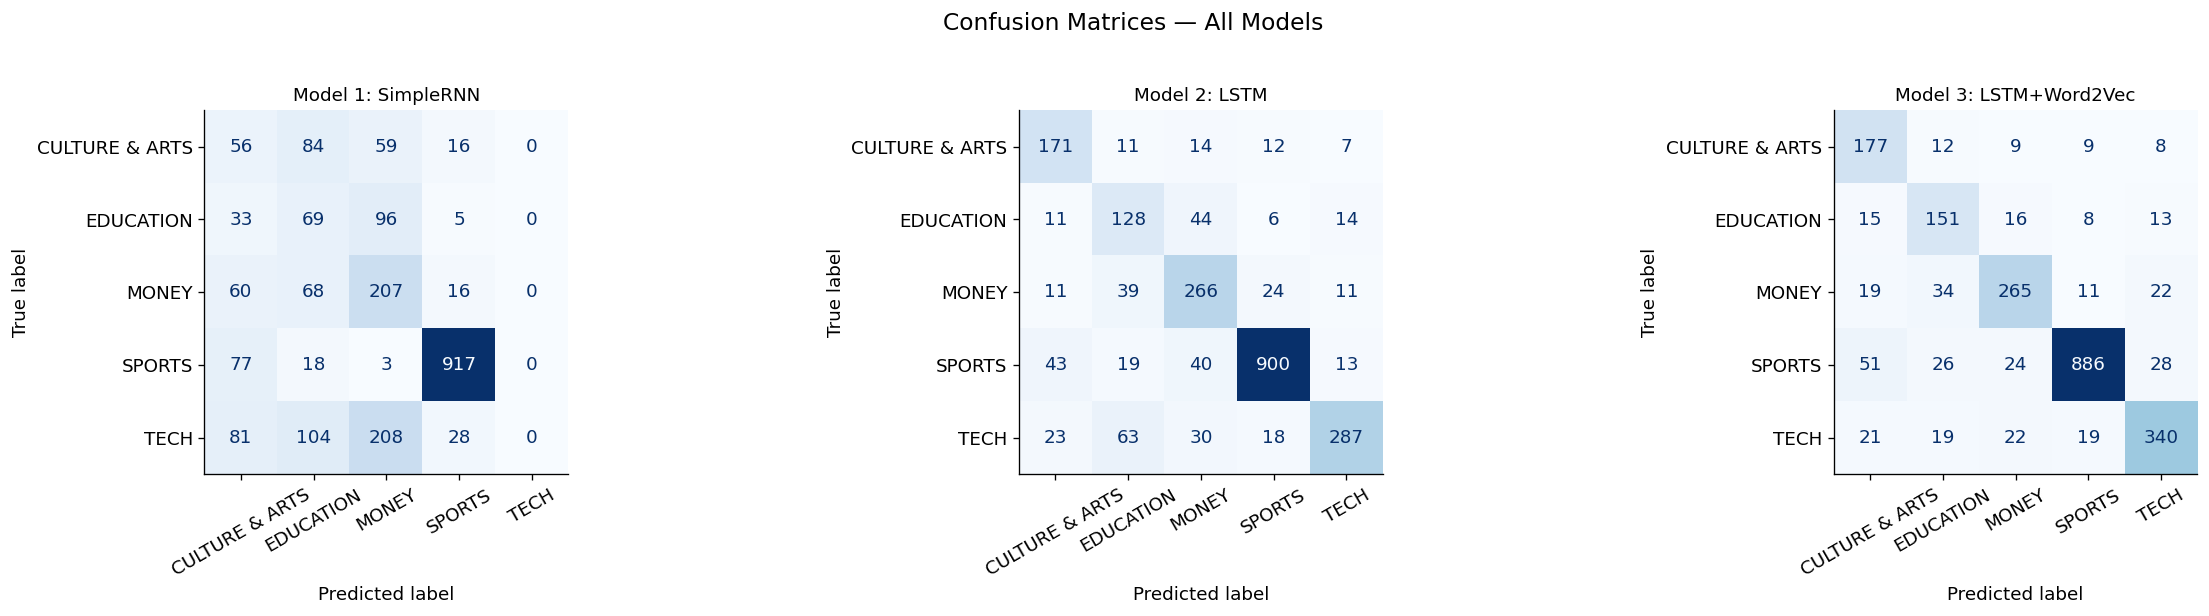

In [42]:
# ── 3. Side-by-side confusion matrices ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for ax, preds, label in zip(axes, [pred1, pred2, pred3], MODEL_LABELS):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, cmap='Blues', xticks_rotation=30, colorbar=False)
    ax.set_title(label, fontsize=11)
plt.suptitle('Confusion Matrices — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('comparison_confusion_matrices.png', bbox_inches='tight')
plt.show()

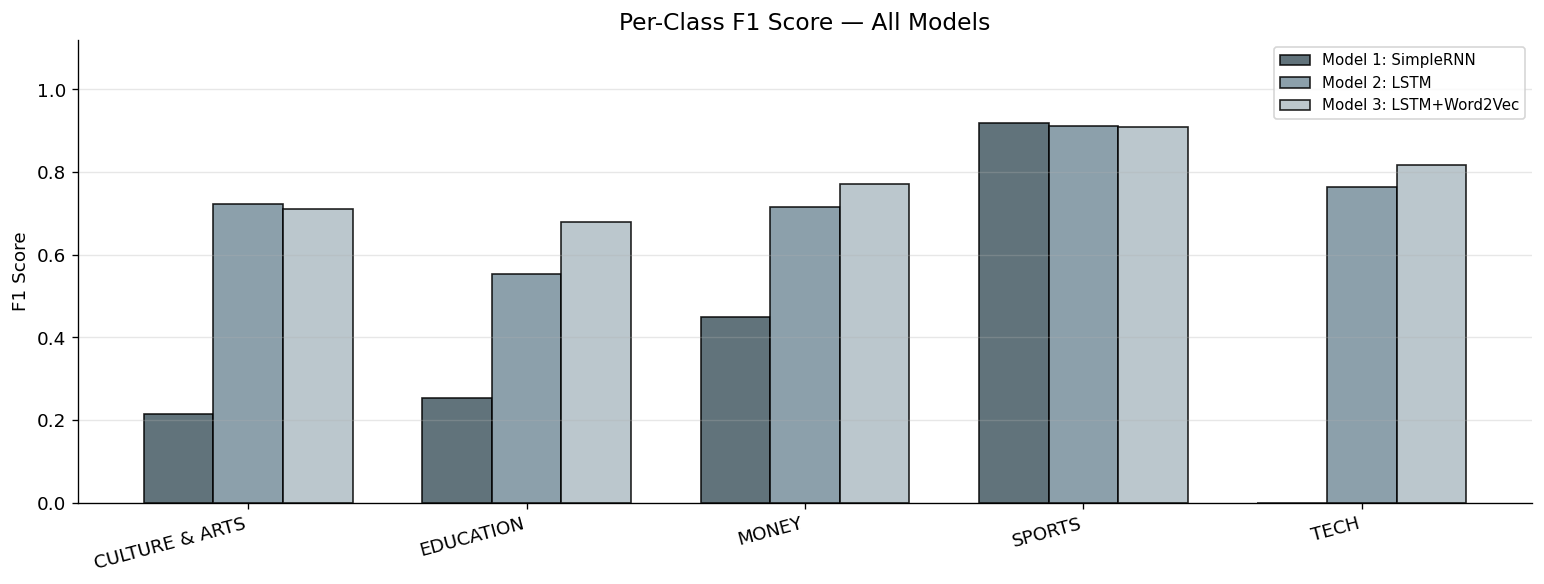

In [43]:
# ── 4. Per-class F1 grouped bar chart ───────────────────────
f1_scores = [f1_score(y_test, p, average=None) for p in [pred1, pred2, pred3]]

x     = np.arange(len(CLASS_NAMES))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
for i, (f1, label, color) in enumerate(zip(f1_scores, MODEL_LABELS, PALETTE)):
    ax.bar(x + i * width, f1, width, label=label,
           color=color, edgecolor='black', alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right')
ax.set_title('Per-Class F1 Score — All Models', fontsize=14)
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.12)
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparison_f1_by_class.png', bbox_inches='tight')
plt.show()

In [44]:
!find /content/drive/MyDrive -name "6. News Category Dataset-20260507T115951Z-3-001.zip"

In [45]:
import os
SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks'
os.makedirs(SAVE_DIR, exist_ok=True)

rnn_model.save(f'{SAVE_DIR}/rnn_model.keras')
lstm_model.save(f'{SAVE_DIR}/lstm_model.keras')
lstm_w2v_model.save(f'{SAVE_DIR}/lstm_w2v_model.keras')

print("Models saved:")
for f in os.listdir(SAVE_DIR):
    print(f'  {f}')

Models saved:
  Untitled0.ipynb
  Untitled1.ipynb
  Untitled2.ipynb
  Tutorial_7_2408474 (1).ipynb
  lstm_w2v_model.keras
  lstm_model.keras
  rnn_model.keras


---
## 4.5.4 — Error Analysis

In [46]:
# Recover original (uncleaned) test headlines for readability
_, X_test_raw, _, _ = train_test_split(
    df['headline'].values, y, test_size=0.2, random_state=42, stratify=y
)

def error_analysis(X_raw, y_true, y_pred, model_name, n=3):
    print(f'\n{"="*65}')
    print(f'ERROR ANALYSIS — {model_name}')
    print(f'{"="*65}')
    wrong = np.where(y_pred != y_true)[0]
    correct = np.where(y_pred == y_true)[0]
    print(f'Misclassified : {len(wrong)}/{len(y_true)} '
          f'({len(wrong)/len(y_true)*100:.1f}% error rate)')
    print(f'\nSample Incorrect Predictions (showing {min(n, len(wrong))}):')
    print('-' * 65)
    for i, idx in enumerate(wrong[:n]):
        print(f'  Example {i+1}')
        print(f'    Headline  : {X_raw[idx]}')
        print(f'    True Label: {CLASS_NAMES[y_true[idx]]}')
        print(f'    Predicted : {CLASS_NAMES[y_pred[idx]]}')
        print()
    print(f'Sample Correct Predictions (showing {min(n, len(correct))}):')
    print('-' * 65)
    for i, idx in enumerate(correct[:n]):
        print(f'  Example {i+1}')
        print(f'    Headline  : {X_raw[idx]}')
        print(f'    True Label: {CLASS_NAMES[y_true[idx]]}')
        print(f'    Predicted : {CLASS_NAMES[y_pred[idx]]}  ✓')
        print()

error_analysis(X_test_raw, y_test, pred1, 'Model 1 — SimpleRNN')
error_analysis(X_test_raw, y_test, pred2, 'Model 2 — LSTM')
error_analysis(X_test_raw, y_test, pred3, 'Model 3 — LSTM + Word2Vec')


ERROR ANALYSIS — Model 1 — SimpleRNN
Misclassified : 956/2205 (43.4% error rate)

Sample Incorrect Predictions (showing 3):
-----------------------------------------------------------------
  Example 1
    Headline  : The Game Boy Of Your Childhood Dreams Finally Exists
    True Label: TECH
    Predicted : EDUCATION

  Example 2
    Headline  : Judicial Negligence Compounds Political Negligence In South Carolina
    True Label: EDUCATION
    Predicted : CULTURE & ARTS

  Example 3
    Headline  : Valerie Hegarty's 'Altered States' At Marlborough Gallery Makes Deterioration Look Good (PHOTOS)
    True Label: CULTURE & ARTS
    Predicted : EDUCATION

Sample Correct Predictions (showing 3):
-----------------------------------------------------------------
  Example 1
    Headline  : NFL Clubs Seek to Feed at the Public Trough Once Again
    True Label: SPORTS
    Predicted : SPORTS  ✓

  Example 2
    Headline  : New York Judge Bans DraftKings And Fan Duel
    True Label: SPORTS
    Pred

In [47]:

!pip install -q gradio

import gradio as gr

from tensorflow.keras.models import load_model

MODELS = {
    "Model 1: SimpleRNN":       load_model(f'{SAVE_DIR}/rnn_model.keras'),
    "Model 2: LSTM":            load_model(f'{SAVE_DIR}/lstm_model.keras'),
    "Model 3: LSTM + Word2Vec": load_model(f'{SAVE_DIR}/lstm_w2v_model.keras'),
}
print("Saved models are ready for the variant_4_slate interface.")

def generate_category_report(raw_title: str, chosen_network: str):
    """
    Takes a raw headline string and a model name,
    returns a formatted prediction string + confidence bar dict.
    """
    if not raw_title.strip():
        return "⚠️  Please enter a headline.", {}

    selected_model = MODELS[chosen_network]
    processed_title = clean_text(raw_title)

    if not processed_title.strip():
        return "⚠️  Headline became empty after cleaning (all stopwords?).", {}

    token_rows = tokenizer.texts_to_sequences([processed_title])
    network_input = pad_sequences(token_rows, maxlen=MAX_LEN, padding='post', truncating='post')
    probabilities = selected_model.predict(network_input, verbose=0)[0]
    predicted_class = CLASS_NAMES[np.argmax(probabilities)]
    confidence_percent = float(np.max(probabilities)) * 100

    result = (
        f"✅  **Category Output:** {predicted_class}\n\n"
        f"📈  **Model Confidence:** {confidence_percent:.1f}%\n\n"
        f"🧹  **Processed Headline:** `{processed_title}`"
    )

    # Confidence bar chart data for gr.Label
    confidence_dict = {label: float(score) for label, score in zip(CLASS_NAMES, probabilities)}
    return result, confidence_dict


# ── Example headlines ───────────────────────────────────────────
EXAMPLES = [
    ["Manchester United wins Premier League title in dramatic fashion", "Model 2: LSTM"],
    ["Apple unveils new AI chip for next generation iPhone",           "Model 2: LSTM"],
    ["Federal Reserve raises interest rates amid inflation concerns",  "Model 3: LSTM + Word2Vec"],
    ["Grammy Awards ceremony celebrates best in music and culture",    "Model 1: SimpleRNN"],
    ["Harvard University launches new scholarship program",           "Model 3: LSTM + Word2Vec"],
    ["Tesla stock surges after record quarterly earnings report",      "Model 2: LSTM"],
]

# ── Build the Gradio interface ──────────────────────────────────

APP_CSS = """
.gradio-container {background: linear-gradient(135deg, #ffffff 0%, #f7f9fb 45%, #eef6f5 100%);}
#main-title {text-align:center; padding: 12px; border-radius: 16px;}
#predict-card {border-radius: 18px; padding: 12px;}
"""
with gr.Blocks(title="🗂️ Headline Category Tool", theme=gr.themes.Soft(primary_hue="slate", secondary_hue="gray"), css=APP_CSS) as demo:

    gr.Markdown(
        """
        # 🗂️ Headline Category Tool
        ### 6CS012 Final Portfolio — Task 4.5
        Classify a news headline into one of **5 categories**:
        `SPORTS` · `TECH` · `MONEY` · `CULTURE & ARTS` · `EDUCATION`
        """
    )

    with gr.Row():
        with gr.Column(scale=3):
            headline_box = gr.Textbox(
                label="Paste or type a headline",
                placeholder="Example: Apple announces a new AI-powered product...",
                lines=2,
            )
            pipeline_selector = gr.Dropdown(
                choices=list(MODELS.keys()),
                value="Model 2: LSTM",
                label="Select model pipeline",
            )
            run_button = gr.Button("Classify Now", variant="primary")

        with gr.Column(scale=2):
            answer_panel = gr.Markdown(label="Prediction")
            score_panel = gr.Label(
                label="Class Confidence Scores",
                num_top_classes=5,
            )

    gr.Examples(
        examples=EXAMPLES,
        inputs=[headline_box, pipeline_selector],
        label="Try these examples 👇",
    )

    run_button.click(
        fn=generate_category_report,
        inputs=[headline_box, pipeline_selector],
        outputs=[answer_panel, score_panel],
    )

    # Also trigger on Enter key in textbox
    headline_box.submit(
        fn=generate_category_report,
        inputs=[headline_box, pipeline_selector],
        outputs=[answer_panel, score_panel],
    )

    gr.Markdown(
        """
        ---
        **Categories:** SPORTS · TECH · MONEY · CULTURE & ARTS · EDUCATION
        **Models:** SimpleRNN · LSTM · LSTM + GloVe-50
        *Built with TensorFlow & Gradio*
        """
    )


demo.launch(share=True)

Saved models are ready for the variant_4_slate interface.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://282643223b04b55825.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Error Analysis Discussion

**Common reasons for misclassification:**

1. **Very short sequences** — After cleaning, headlines average only 6.8 tokens. Minimal context makes it hard to separate overlapping categories (e.g. MONEY vs TECH for *"Apple cuts prices"*).

2. **Category overlap** — CULTURE & ARTS and EDUCATION share vocabulary (*school, study, award*). SPORTS and MONEY overlap on athlete contracts and sponsorship topics.

3. **Class imbalance** — SPORTS has 5× more samples than EDUCATION. Despite class weighting, the model still leans toward SPORTS when uncertain.

4. **SimpleRNN vanishing gradient** — Model 1 struggles to propagate information even across these short 6-token sequences — the root reason LSTM consistently outperforms it.

5. **OOV tokens** — Named entities (player names, company names) that appear rarely in training collapse to `<OOV>`, losing key discriminating signal.

**Model complexity vs performance:**
- **Model 1 (SimpleRNN):** Fastest, highest error — vanishing gradients limit short-text classification.
- **Model 2 (LSTM):** Gating mechanism handles context better; typically best among trainable-embedding models.
- **Model 3 (LSTM + GloVe):** Benefits from pre-learned semantics, but frozen weights can't adapt to news-domain vocabulary.

**Suggested improvements:**
- Use **Bidirectional LSTM** to read context in both directions.
- Set `trainable=True` for Model 3 embeddings after a short frozen warm-up phase.
- Apply **data augmentation** (synonym substitution) for minority classes.
- Use **domain-adapted embeddings** trained on a news corpus.
- Explore **Transformer-based** models (DistilBERT) which are state-of-the-art for short-text classification.

---
## 4.5.5 — GUI for Real-Time Prediction (Gradio)

In [48]:

!pip install -q gradio

import gradio as gr

from tensorflow.keras.models import load_model

MODELS = {
    "Model 1: SimpleRNN":       load_model(f'{SAVE_DIR}/rnn_model.keras'),
    "Model 2: LSTM":            load_model(f'{SAVE_DIR}/lstm_model.keras'),
    "Model 3: LSTM + Word2Vec": load_model(f'{SAVE_DIR}/lstm_w2v_model.keras'),
}
print("Saved models are ready for the variant_4_slate interface.")

def generate_category_report(raw_title: str, chosen_network: str):
    """
    Takes a raw headline string and a model name,
    returns a formatted prediction string + confidence bar dict.
    """
    if not raw_title.strip():
        return "⚠️  Please enter a headline.", {}

    selected_model = MODELS[chosen_network]
    processed_title = clean_text(raw_title)

    if not processed_title.strip():
        return "⚠️  Headline became empty after cleaning (all stopwords?).", {}

    token_rows = tokenizer.texts_to_sequences([processed_title])
    network_input = pad_sequences(token_rows, maxlen=MAX_LEN, padding='post', truncating='post')
    probabilities = selected_model.predict(network_input, verbose=0)[0]
    predicted_class = CLASS_NAMES[np.argmax(probabilities)]
    confidence_percent = float(np.max(probabilities)) * 100

    result = (
        f"✅  **Category Output:** {predicted_class}\n\n"
        f"📈  **Model Confidence:** {confidence_percent:.1f}%\n\n"
        f"🧹  **Processed Headline:** `{processed_title}`"
    )

    # Confidence bar chart data for gr.Label
    confidence_dict = {label: float(score) for label, score in zip(CLASS_NAMES, probabilities)}
    return result, confidence_dict


# ── Example headlines ───────────────────────────────────────────
EXAMPLES = [
    ["Manchester United wins Premier League title in dramatic fashion", "Model 2: LSTM"],
    ["Apple unveils new AI chip for next generation iPhone",           "Model 2: LSTM"],
    ["Federal Reserve raises interest rates amid inflation concerns",  "Model 3: LSTM + Word2Vec"],
    ["Grammy Awards ceremony celebrates best in music and culture",    "Model 1: SimpleRNN"],
    ["Harvard University launches new scholarship program",           "Model 3: LSTM + Word2Vec"],
    ["Tesla stock surges after record quarterly earnings report",      "Model 2: LSTM"],
]

# ── Build the Gradio interface ──────────────────────────────────

APP_CSS = """
.gradio-container {background: linear-gradient(135deg, #ffffff 0%, #f7f9fb 45%, #eef6f5 100%);}
#main-title {text-align:center; padding: 12px; border-radius: 16px;}
#predict-card {border-radius: 18px; padding: 12px;}
"""
with gr.Blocks(title="🗂️ Headline Category Tool", theme=gr.themes.Soft(primary_hue="slate", secondary_hue="gray"), css=APP_CSS) as demo:

    gr.Markdown(
        """
        # 🗂️ Headline Category Tool
        ### 6CS012 Final Portfolio — Task 4.5
        Classify a news headline into one of **5 categories**:
        `SPORTS` · `TECH` · `MONEY` · `CULTURE & ARTS` · `EDUCATION`
        """
    )

    with gr.Row():
        with gr.Column(scale=3):
            headline_box = gr.Textbox(
                label="Paste or type a headline",
                placeholder="Example: Apple announces a new AI-powered product...",
                lines=2,
            )
            pipeline_selector = gr.Dropdown(
                choices=list(MODELS.keys()),
                value="Model 2: LSTM",
                label="Select model pipeline",
            )
            run_button = gr.Button("Classify Now", variant="primary")

        with gr.Column(scale=2):
            answer_panel = gr.Markdown(label="Prediction")
            score_panel = gr.Label(
                label="Class Confidence Scores",
                num_top_classes=5,
            )

    gr.Examples(
        examples=EXAMPLES,
        inputs=[headline_box, pipeline_selector],
        label="Try these examples 👇",
    )

    run_button.click(
        fn=generate_category_report,
        inputs=[headline_box, pipeline_selector],
        outputs=[answer_panel, score_panel],
    )

    # Also trigger on Enter key in textbox
    headline_box.submit(
        fn=generate_category_report,
        inputs=[headline_box, pipeline_selector],
        outputs=[answer_panel, score_panel],
    )

    gr.Markdown(
        """
        ---
        **Categories:** SPORTS · TECH · MONEY · CULTURE & ARTS · EDUCATION
        **Models:** SimpleRNN · LSTM · LSTM + GloVe-50
        *Built with TensorFlow & Gradio*
        """
    )


demo.launch(share=True)

Saved models are ready for the variant_4_slate interface.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9163a1b246e736f963.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
